# Phase 1: Setup and Data Preprocessing 

## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer
import shap

import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

## Load Data and Preprocess

In [2]:
selected_features = ['age_s1', 'gender', 'bmi_s1', 'race', 'mnsao2rh', 'avhrbp', 'neck20', 'ess_s1', 'systbp', 'smokstat_s1', 'rdi3p']
df = pd.read_csv('shhs1-dataset-0.21.0.csv', usecols = selected_features)

print(df.shape)
df.head()

(5804, 11)


,rdi3p,mnsao2rh,avhrbp,gender,race,systbp,neck20,age_s1,smokstat_s1,ess_s1,bmi_s1
0,4.154461,85.0,NaN,1,1,143.0,38.3,55,2.0,6.0,21.777553
1,30.989011,87.0,NaN,1,1,168.0,40.5,78,0.0,14.0,32.950680
2,8.870293,82.0,NaN,2,1,127.0,39.0,77,0.0,5.0,24.114150
3,2.591362,92.0,22.127659,1,1,130.0,39.2,48,0.0,11.0,20.185185
4,6.162162,83.0,NaN,2,2,145.0,32.0,66,2.0,7.0,23.309053


## Deal with Missing Values

In [3]:
print('Count of Missing Values by Variable Before Imputation:')
print(df.isnull().sum())

# Median Imputation for Continuous Variables
continuous_cols = ['bmi_s1', 'mnsao2rh', 'avhrbp', 'neck20', 'systbp', 'ess_s1']
median_imputer = SimpleImputer(strategy = 'median')
df[continuous_cols] = median_imputer.fit_transform(df[continuous_cols])

# Mode Imputation for Categorical Variables
categorical_cols = ['smokstat_s1', 'race', 'gender']
mode_imputer = SimpleImputer(strategy = 'most_frequent')
df[categorical_cols] = mode_imputer.fit_transform(df[categorical_cols])

print('Count of Missing Values by Variable After Imputation:')
print(df.isnull().sum())

Count of Missing Values by Variable Before Imputation:
rdi3p             0
mnsao2rh        166
avhrbp         2692
gender            0
race              0
systbp          113
neck20           29
age_s1            0
smokstat_s1      41
ess_s1          221
bmi_s1           43
dtype: int64
Count of Missing Values by Variable After Imputation:
rdi3p          0
mnsao2rh       0
avhrbp         0
gender         0
race           0
systbp         0
neck20         0
age_s1         0
smokstat_s1    0
ess_s1         0
bmi_s1         0
dtype: int64


## Categorical Encoding

In [4]:
# Define Mappings (Based on Dataset's Dictionary)
gender_map = {
    '1.0': 'Male',
    '2.0': 'Female'
}
race_map = {
    '1.0': 'White', 
    '2.0': 'Black', 
    '3.0': 'Other'
}
smoke_map = {
    '0.0': 'Never', 
    '1.0': 'Former', 
    '2.0': 'Current'
}

# Convert to String & Map to Names
df['gender'] = df['gender'].astype(str).map(gender_map)
df['race'] = df['race'].astype(str).map(race_map)
df['smokstat_s1'] = df['smokstat_s1'].astype(str).map(smoke_map)

# Perform One-Hot Encoding
# drop_first = True Will Create Columns Like 'gender_Female' (Male is Baseline)
df_encoded = pd.get_dummies(df, columns = ['gender', 'race', 'smokstat_s1'], drop_first = True)

# Verification
print("Professional Labels after encoding:", df_encoded.columns.tolist())
display(df_encoded.head())

Professional Labels after encoding: ['rdi3p', 'mnsao2rh', 'avhrbp', 'systbp', 'neck20', 'age_s1', 'ess_s1', 'bmi_s1', 'gender_Male', 'race_Other', 'race_White', 'smokstat_s1_Former', 'smokstat_s1_Never']


,rdi3p,mnsao2rh,avhrbp,systbp,neck20,age_s1,ess_s1,bmi_s1,gender_Male,race_Other,race_White,smokstat_s1_Former,smokstat_s1_Never
0,4.154461,85.0,21.125000,143.0,38.3,55,6.0,21.777553,True,False,True,False,False
1,30.989011,87.0,21.125000,168.0,40.5,78,14.0,32.950680,True,False,True,False,True
2,8.870293,82.0,21.125000,127.0,39.0,77,5.0,24.114150,False,False,True,False,True
3,2.591362,92.0,22.127659,130.0,39.2,48,11.0,20.185185,True,False,True,False,True
4,6.162162,83.0,21.125000,145.0,32.0,66,7.0,23.309053,False,False,False,False,False


## Target Categorization

In [5]:
def categorize_ahi(rdi):
    if rdi < 5:
        return 0 # None
    elif rdi < 15:
        return 1 # Mild
    elif rdi < 30:
        return 2 # Moderate
    else:
        return 3 # Severe

df_encoded['severity_class'] = df_encoded['rdi3p'].apply(categorize_ahi)

# Check the Balance of Classes
print("Patient counts per severity level:")
print(df_encoded['severity_class'].value_counts().sort_index())

Patient counts per severity level:
severity_class
0    1919
1    2041
2    1163
3     681
Name: count, dtype: int64


## Feature Scaling

In [6]:
scale_cols = ['age_s1', 'bmi_s1', 'mnsao2rh', 'avhrbp', 'neck20', 'ess_s1', 'systbp']

scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

print("Preprocessing Complete. Data is now scaled and encoded.")

Preprocessing Complete. Data is now scaled and encoded.


## Feature Engineering

In [7]:
# Interaction Term Between BMI and Age
df_encoded['bmi_age_interaction'] = df_encoded['bmi_s1'] * df_encoded['age_s1']

# Scale New Feature
df_encoded['bmi_age_interaction'] = scaler.fit_transform(df_encoded[['bmi_age_interaction']])

print('Added feature: bmi_age_interaction')

Added feature: bmi_age_interaction


# Phase 2: Exploratory Data Analysis (EDA)

## Distribution of Severity

Text(0, 0.5, 'Number of Patients')

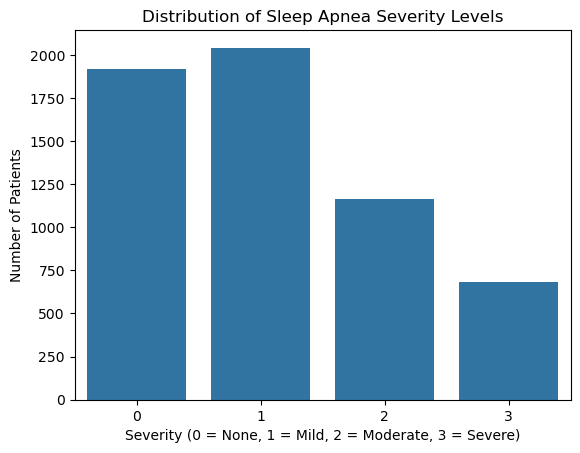

In [8]:
sns.countplot(x = 'severity_class', data = df_encoded)
plt.title('Distribution of Sleep Apnea Severity Levels')
plt.xlabel('Severity (0 = None, 1 = Mild, 2 = Moderate, 3 = Severe)')
plt.ylabel('Number of Patients')

## Boxplot for Clinical Evidence

Text(0.5, 1.0, 'BMI Distribution Across Apnea Severity Levels')

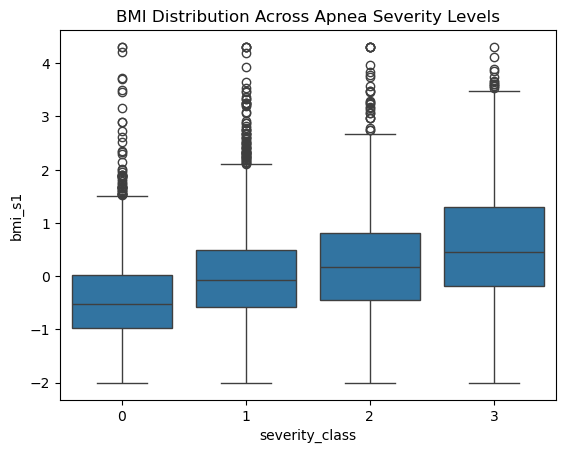

In [9]:
sns.boxplot(x = 'severity_class', y = 'bmi_s1', data = df_encoded)
plt.title('BMI Distribution Across Apnea Severity Levels')

## Correlation Matrix

Text(0.5, 1.0, 'Correlation Heatmap: Clinical Features vs. Apnea Severity')

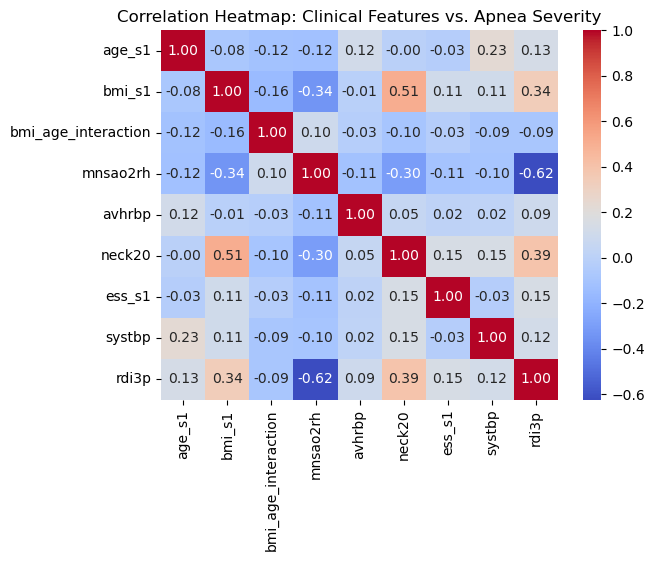

In [10]:
# Select Relevant Features
eda_features = ['age_s1', 'bmi_s1', 'bmi_age_interaction', 'mnsao2rh', 'avhrbp', 'neck20', 'ess_s1', 'systbp', 'rdi3p']
corr_matrix = df_encoded[eda_features].corr()

# Plot Heatmap
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap: Clinical Features vs. Apnea Severity')

## Diagnostic Multicollinearity Checks (VIF)

In [11]:
# Check VIF on Continuous Numeric Deatures
def calculate_vif(df, features):
    # Create Copy of Features & Add Constant Column
    X_vif = df[features].copy()
    X_vif = add_constant(X_vif)

    # Calculate VIF for Each Feature
    vif_data = pd.DataFrame()
    vif_data['feature'] = X_vif.columns
    vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

    # Return Results & Remove 'const' Row for Better Readability
    return vif_data[vif_data['feature'] != 'const'].sort_values(by = 'VIF', ascending = False)

# Define Features Used in Model
vif_features = ['age_s1', 'bmi_s1', 'mnsao2rh', 'avhrbp', 'neck20', 'systbp', 'ess_s1', 'bmi_age_interaction']

print('VIF Scores:')
print(calculate_vif(df_encoded, vif_features))

VIF Scores:
               feature       VIF
2               bmi_s1  1.477852
5               neck20  1.414232
3             mnsao2rh  1.205864
1               age_s1  1.114645
6               systbp  1.089035
8  bmi_age_interaction  1.046160
7               ess_s1  1.032032
4               avhrbp  1.028756


All VIF scores are below 1.5, which means I do not need to drop any variables. I will keep both BMI and Neck Circumference because Random Forest and XGBoost models are naturally robust to feature correlation.

# Phase 3: Validation Strategy (70/15/15)

In [12]:
# Define Features (X) and Target (y)
# Drop raw rdi3p and new severity_class from X
X = df_encoded.drop(columns = ['rdi3p', 'severity_class'], axis = 1)
y = df_encoded['severity_class']

# Split 1: 70% Training, 30% Temporary (for Val/Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.30, random_state = 42, stratify = y)

# Split 2: Split 30% into 2 Equal Halves (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.50, random_state = 42, stratify = y_temp)

print(f'Training Set: {len(X_train)}')
print(f'Validation Set: {len(X_val)}')
print(f'Test Set: {len(X_test)}')

Training Set: 4062
Validation Set: 871
Test Set: 871


# Phase 4: Model Training and Tuning

## Baseline Model: Logistic Regression

In [13]:
# Initialize Baseline Model
log_reg = LogisticRegression(max_iter = 1000, class_weight = 'balanced', random_state = 42)

# Fit Model
log_reg.fit(X_train, y_train)

# Predict on Validation Set
y_val_pred = log_reg.predict(X_val)
y_val_probs = log_reg.predict_proba(X_val)


# Calculate Overall Mutli-class AUC (One vs. Rest)
# 'ovr' compares each class against all others
# 'macro' averages them equally
overall_auc = roc_auc_score(y_val, y_val_probs, multi_class = 'ovr', average = 'macro')

# Calculate AUC for 'Severe' Class (Class 3)
# Directly Checks Project Goal of > 0.80 for Severe OSA
severe_auc = roc_auc_score(y_val == 3, y_val_probs[:, 3])

# Evaluate
print('Baseline Logistic Regression Results (Validation Set)')
print(f'Accuracy: {accuracy_score(y_val, y_val_pred):}')
print(f'Overall Macro-AUC: {overall_auc:}')
print(f'Severe Class AUC {severe_auc}')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred))

Baseline Logistic Regression Results (Validation Set)
Accuracy: 0.5269804822043628
Overall Macro-AUC: 0.7925700197110825
Severe Class AUC 0.8824166857900508

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       288
           1       0.50      0.41      0.45       306
           2       0.39      0.35      0.37       175
           3       0.43      0.66      0.52       102

    accuracy                           0.53       871
   macro avg       0.50      0.53      0.51       871
weighted avg       0.53      0.53      0.52       871



## Additional Models: Random Forest, XGBoost, SVM

In [14]:
# Define Models in Dictionary
models = {
    'Random Forest': RandomForestClassifier(class_weight = 'balanced', random_state = 42),
    'XGBoost': XGBClassifier(eval_metric = 'mlogloss', random_state = 42),
    'SVM': SVC(probability = True, class_weight = 'balanced', random_state = 42)
}

# Loop Through & Calculate Metrics
model_performance = []
for name, model in models.items():
    # Fit Model
    model.fit(X_train, y_train)

    # Get Predictions
    preds = model.predict(X_val)

    # Get Probabilities (for AUC)
    probs = model.predict_proba(X_val)

    # Calculate Metrics
    acc = accuracy_score(y_val, preds)

    # Overall Macro-AUC
    overall_auc = roc_auc_score(y_val, probs, multi_class = 'ovr', average = 'macro')

    # Specific 'Severe' Class AUC (Project Goal)
    severe_auc = roc_auc_score(y_val == 3, probs[:, 3])

    # Store Results
    model_performance.append({
        'Model': name,
        'Accuracy': acc,
        'Overall AUC': overall_auc,
        'Severe AUC': severe_auc
    })

    print(f'{name} Results:')
    print(f'Accuracy: {acc} | Severe AUC: {severe_auc}\n')

# Create Comparison Table
perf_df = pd.DataFrame(model_performance)
print('\nFinal Model Comparison (Validation Set):')
print(perf_df.sort_values(by = 'Severe AUC', ascending = False))

Random Forest Results:
Accuracy: 0.5120551090700345 | Severe AUC: 0.8728486192916698

XGBoost Results:
Accuracy: 0.5154994259471871 | Severe AUC: 0.83861138733777

SVM Results:
Accuracy: 0.513203214695752 | Severe AUC: 0.8648231724419286


Final Model Comparison (Validation Set):
           Model  Accuracy  Overall AUC  Severe AUC
0  Random Forest  0.512055     0.767416    0.872849
2            SVM  0.513203     0.780105    0.864823
1        XGBoost  0.515499     0.754099    0.838611


Looking at all the models (Logistic Regression, Random Forest, XGBoost, and SVM), it appears that Logistic Regression seems to produce the best output. The accuracy is the highest at about 52.58% (not quite to the 75% accuracy goal wanted) and the AUC score is about 0.88 for the Severe class, which meets the goal of the project.

## Hyperparameter Tuning for Lead Candidate Model (Logistic Regression)

In [15]:
# Define Custom Function that Only Looks at Severe Class (Index 3)
def severe_auc_scorer(y_true, y_probs):
    # Matches Logic Used in Manual Check
    return roc_auc_score(y_true == 3, y_probs[:, 3])

# Convert into Scikit-Learn 'Scorer' Object
custom_severe_scorer = make_scorer(severe_auc_scorer, response_method = 'predict_proba')

# Define Parameter Grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100], # smaller values specify stronger regularization
    'penalty': ['l1', 'l2'], # l1 is good for feature selection l2 is standard
    'solver': ['liblinear'] # works well with both l1 and l2
}

# Run Grid Search with Multiple Metrics
print('Tuning Logistic Regression...')
grid_lr = GridSearchCV(
    LogisticRegression(max_iter = 1000, class_weight = 'balanced', random_state = 42),
    param_grid_lr,
    cv = 5,
    scoring = {
        'Severe AUC': custom_severe_scorer, 
        'Accuracy': 'accuracy'
    }, # tuning specifically for accuracy and AUC
    refit = 'Severe AUC', # best model will be the one with best AUC
    return_train_score = True
)

grid_lr.fit(X_train, y_train)

# Pull Results into Table to see Trade-Off
results_df = pd.DataFrame(grid_lr.cv_results_)
print(results_df[['param_C', 'param_penalty', 'mean_test_Severe AUC', 'mean_test_Accuracy']])
best_lr = grid_lr.best_estimator_

Tuning Logistic Regression...
   param_C param_penalty  mean_test_Severe AUC  mean_test_Accuracy
0     0.01            l1              0.853142            0.513047
1     0.01            l2              0.855738            0.509849
2     0.10            l1              0.857199            0.520434
3     0.10            l2              0.855579            0.515510
4     1.00            l1              0.855611            0.518463
5     1.00            l2              0.855298            0.517971
6    10.00            l1              0.855388            0.518956
7    10.00            l2              0.855332            0.519448
8   100.00            l1              0.855329            0.519941
9   100.00            l2              0.855315            0.519941


Hyperparameter optimization confirmed the robustness of the Logistic Regression model. Tuning specifically for the 'Severe' class AUC revealed an optimal configuration using L1 regularization (C = 0.10), which yielded a cross-validated Severe AUC of 0.857. This exceeds the study's primary success threshold of 0.80, demonstrating the model's efficacy as a clinical prioritization tool.

# Phase 5: Visualizing the Confusion Matrix of the Best Model

Text(0.5, 1.0, 'Confusion Matrix: Tuned Logistic Regression (Validation Set)')

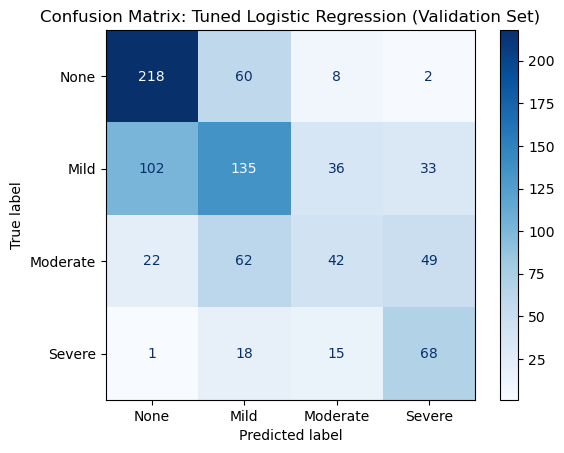

In [16]:
# Get Predictions from Tuned Model
y_val_pred = best_lr.predict(X_val)

# Create Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['None', 'Mild', 'Moderate', 'Severe'])

# Plot
disp.plot(cmap = 'Blues', values_format = 'd')
plt.title('Confusion Matrix: Tuned Logistic Regression (Validation Set)')

# Phase 6: Explainable AI (SHAP Analysis)

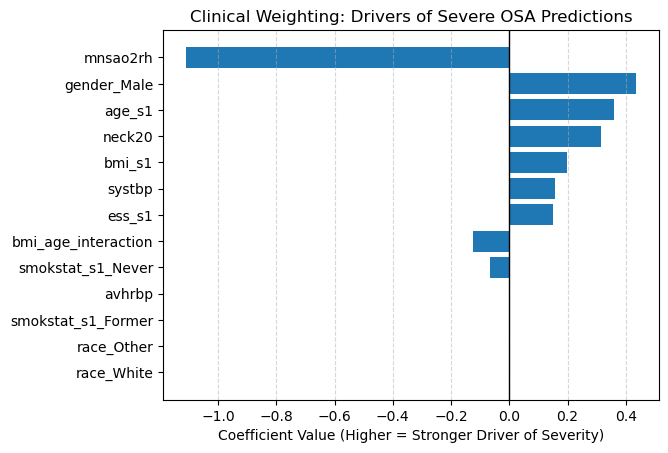

In [17]:
# Extract Coefficients for the 'Severe' class (Index 3)
# Represent 'Log-Odds' Impact of Each Feature
severe_coefs = best_lr.coef_[3]
feature_names = X_val.columns
indices = np.argsort(np.abs(severe_coefs)) # sort by magnitude

# Global Feature Importance
plt.barh(range(len(indices)), severe_coefs[indices])
plt.title("Clinical Weighting: Drivers of Severe OSA Predictions")
plt.xlabel('Coefficient Value (Higher = Stronger Driver of Severity)')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.axvline(0, color = 'black', lw = 1)
plt.grid(axis = 'x', linestyle = '--', alpha = 0.5)

The Logistic Regression model's clinical weights aligned closely with established sleep medicine literature. Male gender, advanced age, neck circumference, and BMI were identified as the primary positive drivers for Severe Obstructive Sleep Apnea classification. Mean oxygen saturation (`mnsao2rh`) acted as the most significant negative predictor, where higher saturation levels strongly correlated with lower severity, which makes sense. The inclusion of the BMI-Age interaction term provided a subtle adjustment to the risk profile, and demographic variables such as race were found to have negligible impact compared to physiological measurements.

## BMI-Age Interaction Logic Check

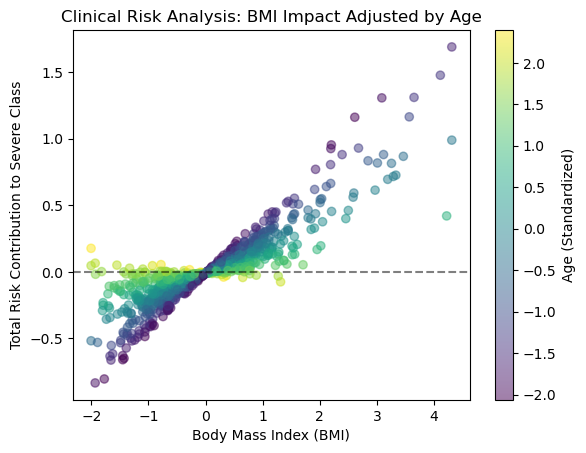

In [18]:
# Calculate Combined Impact of BMI and BMI-Age Interaction Term
# Calculate 'Impact' = (BMI_Value * BMI_Weight) + (Interaction_Value * Interaction_Weight)
# Shows Real Risk Based on Feature Engineering
bmi_weight = best_lr.coef_[3][X_val.columns.get_loc('bmi_s1')]
interact_weight = best_lr.coef_[3][X_val.columns.get_loc('bmi_age_interaction')]

total_bmi_impact = (X_val['bmi_s1'] * bmi_weight) + (X_val['bmi_age_interaction'] * interact_weight)

scatter = plt.scatter(X_val['bmi_s1'], total_bmi_impact, c = X_val['age_s1'], cmap = 'viridis', alpha = 0.5)
plt.colorbar(scatter, label = 'Age (Standardized)')
plt.title("Clinical Risk Analysis: BMI Impact Adjusted by Age")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Total Risk Contribution to Severe Class")
plt.axhline(0, color = 'black', linestyle = '--', alpha = 0.5)

The interaction analysis validates the study's hypothesis that the predictive weight of BMI is affected by patient age. the 'fanning' distribution of risk contributions demonstrates that the model assigns a higher marginal risk to increases in BMI for younger cohorts (darker points) compared to older cohorts (lighter points). This suggests that the model successfully captured the non-linear relationship between obesity and OSA severity across different life stages.

# Phase 7: Final Predictions (Test Set)

In [19]:
final_preds = best_lr.predict(X_test)
final_probs = best_lr.predict_proba(X_test)

# Calculate Final Metrics
final_acc = accuracy_score(y_test, final_preds)
final_severe_auc = roc_auc_score(y_test == 3, final_probs[:, 3])

print('Final Project Results (Test Set):')
print(f'Final Accuracy: {final_acc}')
print(f'Final Severe Class AUC: {final_severe_auc}')
print('\nFinal Classification Report:')
print(classification_report(y_test, final_preds, target_names = ['None', 'Mild', 'Moderate', 'Severe']))

Final Project Results (Test Set):
Final Accuracy: 0.5361653272101033
Final Severe Class AUC: 0.8796884163288202

Final Classification Report:
              precision    recall  f1-score   support

        None       0.65      0.80      0.72       288
        Mild       0.51      0.42      0.46       307
    Moderate       0.41      0.24      0.30       174
      Severe       0.41      0.65      0.50       102

    accuracy                           0.54       871
   macro avg       0.49      0.53      0.50       871
weighted avg       0.52      0.54      0.52       871

